# Feed live JSON: where the size lies and most efficient way to get the data

**Goals:**
1. Load a raw `feed_live` JSON (from warehouse) and inspect its structure.
2. Measure where every byte lives (gameData vs liveData, players vs allPlays vs boxscore).
3. Flatten `allPlays` to a pitch-level table and compare sizes: full JSON vs liveData only vs Parquet.
4. Decide the most efficient way to store and read the data we want (feed as source of truth).

## 1. Load a feed file from the warehouse

In [1]:
import json
import gzip
from pathlib import Path

import pandas as pd

WAREHOUSE = Path("../data/warehouse/mlb")

# Find first available feed (json or json.gz)
def find_feed_path(warehouse: Path, year: int = 2025, stage: str = "all_star"):
    raw_dir = warehouse / str(year) / stage / "raw"
    if not raw_dir.exists():
        raw_dir = warehouse / str(year) / "regular_season" / "raw"
    for ext in ("*.json.gz", "*.json"):
        for p in raw_dir.glob(ext):
            if "feed_live" in p.name:
                return p
    return None

feed_path = find_feed_path(WAREHOUSE)
if feed_path is None:
    # Fallback: any raw feed under warehouse
    feeds = list(WAREHOUSE.rglob("raw/*_feed_live.json*"))
    feed_path = feeds[0] if feeds else None

print(f"Using: {feed_path}" if feed_path else "No feed found. Set feed_path manually.")
print(f"File size on disk: {feed_path.stat().st_size:,} B" if feed_path else "")

Using: ../data/warehouse/mlb/2025/all_star/raw/game_778566_20250715_feed_live.json.gz
File size on disk: 154,013 B


In [2]:
def load_feed(path: Path) -> dict:
    if path.suffix == ".gz" or path.name.endswith(".json.gz"):
        with gzip.open(path, "rt", encoding="utf-8") as f:
            return json.load(f)
    with open(path, encoding="utf-8") as f:
        return json.load(f)

feed = load_feed(feed_path) if feed_path else {}
print(f"Top-level keys: {list(feed.keys())}")
print(f"gameData keys: {list(feed.get('gameData', {}).keys())}")
print(f"liveData keys: {list(feed.get('liveData', {}).keys())}")

Top-level keys: ['copyright', 'gamePk', 'link', 'metaData', 'gameData', 'liveData']
gameData keys: ['game', 'datetime', 'status', 'teams', 'players', 'venue', 'officialVenue', 'weather', 'gameInfo', 'review', 'absChallenges', 'flags', 'alerts', 'probablePitchers', 'officialScorer', 'primaryDatacaster', 'moundVisits']
liveData keys: ['plays', 'linescore', 'boxscore', 'decisions', 'leaders']


## 2. Measure where the size lies (minified JSON bytes)

In [3]:
def size_bytes(obj) -> int:
    """Size of object as minified JSON (no indent)."""
    return len(json.dumps(obj, ensure_ascii=False))

def breakdown(feed: dict) -> list[tuple[str, int]]:
    gd = feed.get("gameData", {})
    ld = feed.get("liveData", {})
    total = size_bytes(feed)
    parts = []
    
    # Root
    parts.append(("copyright + gamePk + link + metaData", total - size_bytes(gd) - size_bytes(ld)))
    
    # gameData
    parts.append(("gameData (total)", size_bytes(gd)))
    parts.append(("  gameData.players", size_bytes(gd.get("players", {}))))
    parts.append(("  gameData.teams", size_bytes(gd.get("teams", {}))))
    parts.append(("  gameData.venue", size_bytes(gd.get("venue", {}))))
    rest_gd = size_bytes(gd) - size_bytes(gd.get("players",{})) - size_bytes(gd.get("teams",{})) - size_bytes(gd.get("venue",{}))
    parts.append(("  gameData.rest (game, datetime, weather, etc.)", rest_gd))
    
    # liveData
    parts.append(("liveData (total)", size_bytes(ld)))
    all_plays = ld.get("plays", {}).get("allPlays", [])
    parts.append(("  liveData.plays.allPlays", size_bytes(all_plays)))
    parts.append(("  liveData.linescore", size_bytes(ld.get("linescore", {}))))
    parts.append(("  liveData.boxscore", size_bytes(ld.get("boxscore", {}))))
    parts.append(("  liveData.decisions + leaders", size_bytes(ld.get("decisions", {})) + size_bytes(ld.get("leaders", {}))))
    
    return parts

In [4]:
parts = breakdown(feed)
total = size_bytes(feed)

df_size = pd.DataFrame(parts, columns=["Component", "Bytes"])
df_size["Pct"] = (100 * df_size["Bytes"] / total).round(1)
df_size["KB"] = (df_size["Bytes"] / 1024).round(1)
pd.set_option("display.max_rows", None)
display(df_size)

,Component,Bytes,Pct,KB
0,copyright + gamePk + link + metaData,426,0.0,0.4
1,gameData (total),74384,7.5,72.6
2,gameData.players,70029,7.1,68.4
3,gameData.teams,1926,0.2,1.9
4,gameData.venue,631,0.1,0.6
5,"gameData.rest (game, datetime, weather, etc.)",1798,0.2,1.8
6,liveData (total),911308,92.4,889.9
7,liveData.plays.allPlays,622853,63.2,608.3
8,liveData.linescore,3643,0.4,3.6
9,liveData.boxscore,259845,26.4,253.8


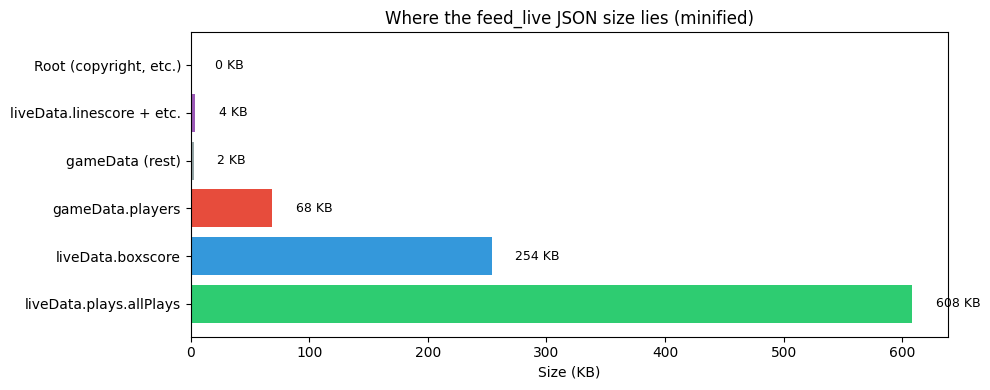

In [6]:
# Visual: where the size lies
import matplotlib.pyplot as plt

# Only top-level or meaningful rows for the bar chart
# parts: 0=root, 2=players, 4+5=venue+rest, 7=allPlays, 8=linescore, 9=boxscore, 10=decisions+leaders
plot_rows = [
    ("liveData.plays.allPlays", parts[7][1]),
    ("liveData.boxscore", parts[9][1]),
    ("gameData.players", parts[2][1]),
    ("gameData (rest)", parts[4][1] + parts[5][1]),
    ("liveData.linescore + etc.", parts[8][1] + parts[10][1]),
    ("Root (copyright, etc.)", parts[0][1]),
]
labels = [r[0] for r in plot_rows]
sizes = [r[1] for r in plot_rows]
colors = ["#2ecc71", "#3498db", "#e74c3c", "#95a5a6", "#9b59b6", "#bdc3c7"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels, [s / 1024 for s in sizes], color=colors)
ax.set_xlabel("Size (KB)")
ax.set_title("Where the feed_live JSON size lies (minified)")
for b, s in zip(bars, sizes):
    ax.text(b.get_width() + 20, b.get_y() + b.get_height()/2, f"{s/1024:.0f} KB", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. What's inside one pitch (allPlays → playEvents)

In [7]:
all_plays = feed.get("liveData", {}).get("plays", {}).get("allPlays", [])
n_plays = len(all_plays)
n_pitches = sum(1 for p in all_plays for e in p.get("playEvents", []) if e.get("isPitch") and e.get("pitchData"))

print(f"Plays (at-bats): {n_plays}")
print(f"Pitches: {n_pitches}")
print(f"Avg bytes per pitch (allPlays total / n_pitches): {size_bytes(all_plays) / max(n_pitches, 1):,.0f} B")

# One pitch event keys
for p in all_plays[:3]:
    for ev in p.get("playEvents", []):
        if ev.get("isPitch") and ev.get("pitchData"):
            print(f"\nOne pitch event keys: {list(ev.keys())}")
            print(f"  pitchData keys: {list(ev.get('pitchData', {}).keys())}")
            print(f"  details keys: {list(ev.get('details', {}).keys())}")
            print(f"  Size of this single pitch (JSON): {size_bytes(ev):,} B")
            break
    else:
        continue
    break

Plays (at-bats): 80
Pitches: 295
Avg bytes per pitch (allPlays total / n_pitches): 2,111 B

One pitch event keys: ['details', 'count', 'pitchData', 'index', 'playId', 'pitchNumber', 'startTime', 'endTime', 'isPitch', 'type']
  pitchData keys: ['startSpeed', 'endSpeed', 'strikeZoneTop', 'strikeZoneBottom', 'strikeZoneWidth', 'strikeZoneDepth', 'coordinates', 'breaks', 'zone', 'typeConfidence', 'plateTime', 'extension']
  details keys: ['call', 'description', 'code', 'ballColor', 'trailColor', 'isInPlay', 'isStrike', 'isBall', 'type', 'isOut', 'hasReview']
  Size of this single pitch (JSON): 1,390 B


## 4. Flatten allPlays to a pitch-level DataFrame (feed as source)

In [16]:
def flatten_one_pitch(ev: dict, game_pk: int, inning: int, at_bat_index: int) -> dict:
    pd_ = ev.get("pitchData") or {}
    det = ev.get("details") or {}
    coords = pd_.get("coordinates") or {}
    breaks = pd_.get("breaks") or {}
    count = ev.get("count") or {}
    hd = ev.get("hitData") or {}
    hit_coords = hd.get("coordinates") or {}
    return {
        "game_pk": game_pk,
        "inning": inning,
        "at_bat_index": at_bat_index,
        "pitch_number": ev.get("pitchNumber"),
        "play_id": ev.get("playId"),
        "startTime": ev.get("startTime"),
        "endTime": ev.get("endTime"),
        "startSpeed": pd_.get("startSpeed"),
        "endSpeed": pd_.get("endSpeed"),
        "zone": pd_.get("zone"),
        "plateTime": pd_.get("plateTime"),
        "extension": pd_.get("extension"),
        "typeConfidence": pd_.get("typeConfidence"),
        "plate_x": coords.get("pX"),
        "plate_z": coords.get("pZ"),
        "pfx_x": coords.get("pfxX"),
        "pfx_z": coords.get("pfxZ"),
        "call_code": det.get("code"),
        "call_description": det.get("description"),
        "is_strike": det.get("isStrike"),
        "is_ball": det.get("isBall"),
        "is_in_play": det.get("isInPlay"),
        "pitch_type_code": det.get("type", {}).get("code") if isinstance(det.get("type"), dict) else None,
        "pitch_type_desc": det.get("type", {}).get("description") if isinstance(det.get("type"), dict) else None,
        "sz_top": pd_.get("strikeZoneTop"),
        "sz_bot": pd_.get("strikeZoneBottom"),
        "spin_rate": breaks.get("spinRate"),
        "spin_direction": breaks.get("spinDirection"),
        "balls": count.get("balls"),
        "strikes": count.get("strikes"),
        "outs": count.get("outs"),
        # hitData (only when isInPlay) — exit velo, launch angle from feed
        "launch_speed_feed": hd.get("launchSpeed"),
        "launch_angle_feed": hd.get("launchAngle"),
        "total_distance_feed": hd.get("totalDistance"),
        "trajectory_feed": hd.get("trajectory"),
        "hardness_feed": hd.get("hardness"),
        "hit_location_feed": hd.get("location"),
        "coord_x_feed": hit_coords.get("coordX"),
        "coord_y_feed": hit_coords.get("coordY"),
    }

rows = []
game_pk = feed.get("gamePk")
for play in all_plays:
    inn = play["about"]["inning"]
    ab_idx = play["atBatIndex"]
    for ev in play.get("playEvents", []):
        if ev.get("isPitch") and ev.get("pitchData"):
            rows.append(flatten_one_pitch(ev, game_pk, inn, ab_idx))

df_pitches = pd.DataFrame(rows)
print(f"Flattened: {len(df_pitches)} rows, {len(df_pitches.columns)} columns")
display(df_pitches.head())

Flattened: 295 rows, 39 columns


,game_pk,inning,at_bat_index,pitch_number,play_id,startTime,endTime,startSpeed,endSpeed,zone,...,strikes,outs,launch_speed_feed,launch_angle_feed,total_distance_feed,trajectory_feed,hardness_feed,hit_location_feed,coord_x_feed,coord_y_feed
0,778566,1,0,1,1ddbc53b-1d84-3efa-ba00-a5cfc7e151bc,2025-07-16T00:25:15.577Z,2025-07-16T00:25:19.035Z,99.4,90.9,1,...,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,778566,1,0,2,3f940ca6-c0b7-3e54-bb06-70fb6d0acb0d,2025-07-16T00:25:34.006Z,2025-07-16T00:25:38.352Z,97.9,90.0,11,...,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,778566,1,0,3,7be1e68a-4747-3b5a-8ac0-60bbb3c8a352,2025-07-16T00:25:49.367Z,2025-07-16T00:25:55.184Z,99.4,91.8,11,...,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,778566,1,0,4,47708616-a24a-335c-84d8-33d49c3688e5,2025-07-16T00:26:06.917Z,2025-07-16T00:26:11.336Z,98.5,91.0,14,...,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,778566,1,0,5,d56085b0-8522-384f-878c-304b19314582,2025-07-16T00:26:24.606Z,2025-07-16T00:26:28.207Z,99.7,91.8,2,...,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4b. Compare: pitches_enriched (Statcast) vs flattened feed

We load the same game's **pitches_enriched.parquet** (Statcast + play_id from feed) and compare columns and values to the **flattened feed** (df_pitches). One motivation for using pybaseball was **bat_speed** and other Statcast-only metrics — we'll see what's only in enriched vs only in feed vs in both.

In [17]:
# From feed_path derive game_pk and date to find pitches_enriched
# e.g. game_778566_20250715_feed_live.json.gz -> 778566, 20250715
import re
if feed_path:
    m = re.search(r"game_(\d+)_(\d+)_feed_live", feed_path.stem.replace(".json", ""))
    game_pk, game_date = (m.group(1), m.group(2)) if m else (None, None)
else:
    game_pk, game_date = feed.get("gamePk"), None

# pitches_enriched lives in same stage folder: .../pitches_enriched/game_{pk}_{date}_pitches_enriched.parquet
enriched_path = None
if feed_path and game_pk and game_date:
    # Replace /raw/ with /pitches_enriched/ and filename
    enriched_path = feed_path.parent.parent / "pitches_enriched" / f"game_{game_pk}_{game_date}_pitches_enriched.parquet"
if enriched_path and enriched_path.exists():
    df_enriched = pd.read_parquet(enriched_path)
    print(f"Loaded pitches_enriched: {enriched_path.name}")
    print(f"  Shape: {df_enriched.shape[0]} rows, {df_enriched.shape[1]} columns")
else:
    df_enriched = None
    print("pitches_enriched not found for this game; set enriched_path manually or run pipeline first.")

Loaded pitches_enriched: game_778566_20250715_pitches_enriched.parquet
  Shape: 295 rows, 76 columns


In [18]:
if df_enriched is not None:
    feed_cols = set(df_pitches.columns)
    enriched_cols = set(df_enriched.columns)
    only_enriched = sorted(enriched_cols - feed_cols)
    only_feed = sorted(feed_cols - enriched_cols)
    both = sorted(feed_cols & enriched_cols)

    print("Column comparison (flattened feed vs pitches_enriched)")
    print("=" * 60)
    print(f"Only in pitches_enriched (Statcast/pybaseball): {len(only_enriched)}")
    print("  ", only_enriched[:20], "..." if len(only_enriched) > 20 else "")
    if "bat_speed" in only_enriched:
        print("  >>> bat_speed is one of them (motivation for using pybaseball).")
    print()
    print(f"Only in flattened feed: {len(only_feed)}")
    print("  ", only_feed)
    print()
    print(f"In both (same or similar concept): {len(both)}")
    print("  ", both)

    # Summary table
    comp = []
    for c in only_enriched:
        comp.append({"column": c, "in_feed": False, "in_enriched": True, "notes": "Statcast only"})
    for c in only_feed:
        comp.append({"column": c, "in_feed": True, "in_enriched": False, "notes": "Feed only"})
    for c in both[:15]:
        comp.append({"column": c, "in_feed": True, "in_enriched": True, "notes": "Both"})
    if len(both) > 15:
        comp.append({"column": f"... and {len(both)-15} more", "in_feed": True, "in_enriched": True, "notes": ""})
    display(pd.DataFrame(comp))

Column comparison (flattened feed vs pitches_enriched)
Only in pitches_enriched (Statcast/pybaseball): 63
   ['age_bat', 'age_pit', 'arm_angle', 'at_bat_number', 'attack_angle', 'attack_direction', 'away_score', 'away_team', 'babip_value', 'bat_speed', 'bat_win_exp', 'batter', 'bb_type', 'delta_home_win_exp', 'delta_pitcher_run_exp', 'delta_run_exp', 'des', 'description', 'effective_speed', 'estimated_ba_using_speedangle'] ...
  >>> bat_speed is one of them (motivation for using pybaseball).

Only in flattened feed: 26
   ['at_bat_index', 'call_code', 'call_description', 'coord_x_feed', 'coord_y_feed', 'endSpeed', 'endTime', 'extension', 'hardness_feed', 'hit_location_feed', 'is_ball', 'is_in_play', 'is_strike', 'launch_angle_feed', 'launch_speed_feed', 'outs', 'pitch_type_code', 'pitch_type_desc', 'plateTime', 'spin_direction', 'spin_rate', 'startSpeed', 'startTime', 'total_distance_feed', 'trajectory_feed', 'typeConfidence']

In both (same or similar concept): 13
   ['balls', 'game_p

,column,in_feed,in_enriched,notes
0,age_bat,False,True,Statcast only
1,age_pit,False,True,Statcast only
2,arm_angle,False,True,Statcast only
3,at_bat_number,False,True,Statcast only
4,attack_angle,False,True,Statcast only
5,attack_direction,False,True,Statcast only
6,away_score,False,True,Statcast only
7,away_team,False,True,Statcast only
8,babip_value,False,True,Statcast only
9,bat_speed,False,True,Statcast only


In [19]:
# Merge on play_id and compare values for overlapping concepts
if df_enriched is not None and "play_id" in df_pitches.columns and "play_id" in df_enriched.columns:
    merged = df_enriched.merge(
        df_pitches,
        on="play_id",
        how="inner",
        suffixes=("_enriched", "_feed"),
    )
    print(f"Merged on play_id: {len(merged)} rows (should match pitch count if 1:1).")
    # Compare key columns: same concept, possibly different names/values
    # Same concept: enriched uses release_speed, feed uses startSpeed
    if "release_speed" in merged.columns and "startSpeed" in merged.columns:
        diff = (merged["release_speed"] - merged["startSpeed"]).abs()
        print(f"  release_speed (enriched) vs startSpeed (feed): max |diff| = {diff.max():.4f}")
    for col in ["zone", "plate_x", "plate_z", "balls", "strikes"]:
        c_enc, c_feed = col + "_enriched", col + "_feed"
        if c_enc in merged.columns and c_feed in merged.columns:
            d = (merged[c_enc].astype(float) - merged[c_feed].astype(float)).abs()
            print(f"  {col}: max |enriched - feed| = {d.max():.4f}")
    # Show bat_speed in enriched (NaN in feed)
    if "bat_speed" in merged.columns:
        non_null = merged["bat_speed"].notna().sum()
        print(f"\nbat_speed (Statcast only): non-null in {non_null} of {len(merged)} rows.")
    show = [c for c in ["play_id", "release_speed", "startSpeed", "zone_enriched", "zone_feed", "plate_x_enriched", "plate_x_feed"] if c in merged.columns]
    display(merged[show].head(10) if show else merged.head())

Merged on play_id: 295 rows (should match pitch count if 1:1).
  release_speed (enriched) vs startSpeed (feed): max |diff| = 0.0000
  zone: max |enriched - feed| = 10.0000
  plate_x: max |enriched - feed| = 0.0050
  plate_z: max |enriched - feed| = 0.0050
  balls: max |enriched - feed| = 1.0000
  strikes: max |enriched - feed| = 1.0000

bat_speed (Statcast only): non-null in 149 of 295 rows.


,play_id,release_speed,startSpeed,zone_enriched,zone_feed,plate_x_enriched,plate_x_feed
0,372160c9-6e0a-36f9-b74f-56d8039e3538,85.6,85.6,13,13,-0.40,-0.399464
1,b73a4f77-0d57-374f-9214-0222d95ec091,99.8,99.8,12,12,0.05,0.046057
2,2d2ac518-7f2a-3172-ac43-9eaf147583d5,86.9,86.9,12,12,0.03,0.026714
3,3e2b1602-e54e-3d4b-8cfd-22fa83b308de,100.4,100.4,12,12,0.66,0.663304
4,e72fc252-6825-3382-b903-8d49f8878542,100.7,100.7,12,12,0.54,0.536687
5,0216f498-969c-35f4-9a7f-649b1a811074,100.2,100.2,5,5,-0.25,-0.251721
6,f2f8c245-76ab-3501-8a32-df1c93868ae4,100.1,100.1,9,9,0.66,0.661343
7,76050c58-b129-37f2-a1e7-75b1f373081f,92.1,92.1,13,13,-0.47,-0.467210
8,987eda40-bb6a-3e19-af05-041f6201a27a,99.7,99.7,13,13,-0.89,-0.887135
9,fb505b65-9088-3578-8a64-09cf7146b9de,97.8,97.8,11,1,-0.38,-0.377346


## 5. Compare sizes: full JSON vs liveData only vs flattened Parquet

In [20]:
ld = feed.get("liveData", {})

sizes = {
    "Full feed (minified JSON)": size_bytes(feed),
    "liveData only (minified JSON)": size_bytes(ld),
    "allPlays only (minified JSON)": size_bytes(all_plays),
}

# Write Parquet to temp and measure
parquet_path = Path("/tmp/feed_pitches_sample.parquet")
df_pitches.to_parquet(parquet_path, index=False)
sizes["Flattened pitches (Parquet, snappy)"] = parquet_path.stat().st_size
parquet_path.unlink()

comparison = pd.DataFrame([(k, v, f"{v/1024:.1f} KB") for k, v in sizes.items()], columns=["Format", "Bytes", "Size"])
comparison["Ratio vs full"] = (comparison["Bytes"] / sizes["Full feed (minified JSON)"]).round(2)
display(comparison)

,Format,Bytes,Size,Ratio vs full
0,Full feed (minified JSON),986118,963.0 KB,1.00
1,liveData only (minified JSON),911308,889.9 KB,0.92
2,allPlays only (minified JSON),622853,608.3 KB,0.63
3,"Flattened pitches (Parquet, snappy)",66938,65.4 KB,0.07


In [21]:
# Same comparison with current file-on-disk (gzipped)
disk_gz = feed_path.stat().st_size if feed_path else 0
print(f"Current file on disk (.json.gz): {disk_gz:,} B ({disk_gz/1024:.1f} KB)")
print(f"Flattened Parquet would be: {sizes['Flattened pitches (Parquet, snappy)']:,} B ({sizes['Flattened pitches (Parquet, snappy)']/1024:.1f} KB)")
print(f"Parquet vs gzipped JSON: {sizes['Flattened pitches (Parquet, snappy)'] / max(disk_gz, 1):.2f}x" if disk_gz else "")

Current file on disk (.json.gz): 154,013 B (150.4 KB)
Flattened Parquet would be: 66,938 B (65.4 KB)
Parquet vs gzipped JSON: 0.43x


## 6. Conclusion: most efficient way to get the data we want

- **Source of truth:** feed_live (we trust it more than Savant).
- **Heavy part:** allPlays (pitch-by-pitch); we don't want to leave it out.
- **Efficient approach:**
  1. Keep fetching and optionally storing raw feed (e.g. .json.gz) for audit/reprocess.
  2. **Derive a Parquet from allPlays** (and optionally boxscore for umpires, team stats) right after ingest — same data, ~10–20x smaller than minified JSON, queryable (filter by game/date, select columns).
  3. Run daily jobs (HR runner, etc.) from the feed-derived Parquet so you never open the full JSON in production.
- **Optional:** Also flatten boxscore (officials, teamStats, players stats) into Parquet or a separate table if you need umpires/weather/roster in the same pipeline.

## 7. Phase 0 — Multi-season disk footprint

Summarize **all numeric season folders** under the warehouse: raw game files vs `pitches_enriched` vs **`players_registry.json`** (bios dedupe). See repo doc **[`docs/PHASE0_STORAGE_FORMULA.md`](../docs/PHASE0_STORAGE_FORMULA.md)** for the recommended **data vs space formula**.

**Theoretical duplicate bios cost:** if `gameData.players` is ~7% of minified feed per game, storing bios only in `players_registry.json` avoids repeating that ~7% in every raw file (optional future “slim raw” mode). The cell below prints `players_json × n_games` vs a single registry file size.

---

**Short review**

- **What we're doing:** Inspecting the MLB `feed_live` JSON: where the bytes go (gameData vs liveData, allPlays vs boxscore vs players), flattening `allPlays` (including hitData) to a pitch-level table, and comparing the same game's feed-derived data with `pitches_enriched` Parquet.
- **What we're trying to achieve:** Reduce warehouse size while keeping feed as the source of truth; understand that the bulk of the feed is allPlays; and confirm that the most efficient way to work with pitch-level data is to derive Parquet from the feed (with optional Statcast enrichment for fields like bat_speed). Raw stays in .json.gz for audit; analytics use flattened Parquet.

In [ ]:
import pandas as pd

path = "/Users/gilrojasb/Desktop/Mallitalytics_VS/MLB/data/warehouse/mlb/2025/regular_season/pitches_enriched/game_776136_20250928_pitches_enriched.parquet"
df = pd.read_parquet(path)

# Pitches per pitcher (with pitch-type mix)
by_pitcher = (
    df.groupby("pitcher")
    .agg(
        pitches=("pitch_number", "count"),
        pitch_types=("pitch_name", lambda s: s.value_counts().head(3).to_dict()),
    )
    .reset_index()
)
by_pitcher

: 

In [ ]:
# Multi-season warehouse summary (adjust WAREHOUSE if needed)
WAREHOUSE_SUM = Path("../data/warehouse/mlb")


def summarize_seasons(warehouse: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(warehouse.iterdir(), key=lambda x: x.name):
        if not p.is_dir() or not p.name.isdigit():
            continue
        season = int(p.name)
        raw_files = list(p.rglob("raw/*_feed_live.json*"))
        pe_files = list(p.rglob("pitches_enriched/*.parquet"))
        raw_bytes = sum(f.stat().st_size for f in raw_files)
        pe_bytes = sum(f.stat().st_size for f in pe_files)
        reg = p / "players_registry.json"
        reg_b = reg.stat().st_size if reg.exists() else 0
        rows.append(
            {
                "season": season,
                "n_raw": len(raw_files),
                "raw_mb": round(raw_bytes / 1e6, 2),
                "n_parquet": len(pe_files),
                "parquet_mb": round(pe_bytes / 1e6, 2),
                "registry_kb": round(reg_b / 1024, 1) if reg_b else 0,
                "raw_per_parquet": round(raw_bytes / pe_bytes, 1) if pe_bytes else None,
            }
        )
    return pd.DataFrame(rows)


df_sum = summarize_seasons(WAREHOUSE_SUM)
display(df_sum)

# Rough duplicate-bios estimate: this game's gameData.players size × total raw files in warehouse
if feed_path and feed and not df_sum.empty:
    gd = feed.get("gameData") or {}
    p_bytes = len(json.dumps(gd.get("players") or {}, ensure_ascii=False))
    total_bytes = size_bytes(feed)
    n_games = int(df_sum["n_raw"].sum())
    dup_est_mb = p_bytes * n_games / 1e6
    print(
        f"Sample gameData.players minified: {p_bytes/1024:.1f} KB ({100*p_bytes/total_bytes:.1f}% of this feed)\n"
        f"× {n_games} raw files (all seasons above) ≈ {dup_est_mb:.1f} MB if that block were unique per file\n"
        f"→ players_registry.json (one per season) dedupes bios for digest/API/cards."
    )

---

## 8. What you'd lose without raw feed: exclusive data audit

**`pitches_enriched` (Statcast parquet) already covers:** pitch physics, spin, movement, plate location, Statcast expected metrics, win probability, run expectancy, batter/pitcher IDs, base-runner flags, game score, etc. — all at the individual pitch level, plus `play_id` from the feed.

**What lives *only* in the raw feed JSON (and nowhere in parquet):**

| Section | Content | Use cases |
|---|---|---|
| `liveData.boxscore` (~190 KB, 26% of file) | Traditional batting/pitching line per player (H, AB, RBI, IP, ER, …) + team totals | Post-game stat lines, traditional box scores |
| `liveData.linescore` (~3 KB) | Inning-by-inning R/H/E by team | Game narrative, inning summaries |
| `liveData.decisions` | Official W / L / SV pitcher decisions | Game results, fantasy |
| `gameData.weather` | Temp, condition, wind speed + direction | Weather analysis, park factor studies |
| `gameData.flags` | No-hitter / perfect game in progress | Narrative alerts |
| `allPlays[].runners` | Where each runner started/ended on *every* play | Baserunning analytics, defensive positioning |
| `allPlays[].result` | Official at-bat result description + RBI count | Play-by-play text |
| `allPlays` non-pitch events | Stolen base attempts, pickoffs, mound visits, manager challenges, subs as separate events | Game flow, strategy analytics |
| `gameData.players` | Full roster bios (position, bats/throws, age, birthdate, …) | *Mostly* covered by `players_registry.json` — shared deduplication |

The cells below show the exact byte sizes for each exclusive section and calculate how much you save by gzipping all existing plain `.json` files.

In [1]:
import json
import gzip
import io
from pathlib import Path

WAREHOUSE = Path("../data/warehouse/mlb")

# ── Pick a representative plain .json file ─────────────────────────────────
sample = None
for p in (WAREHOUSE / "2025" / "regular_season" / "raw").glob("*_feed_live.json"):
    sample = p
    break

assert sample is not None, "No plain .json raw file found; edit path above"

raw_text = sample.read_text(encoding="utf-8")
feed_s = json.loads(raw_text)
total_b = len(raw_text.encode("utf-8"))

gd = feed_s.get("gameData", {})
ld = feed_s.get("liveData", {})
plays = ld.get("plays", {}).get("allPlays", [])

def jbytes(obj):
    return len(json.dumps(obj, ensure_ascii=False).encode("utf-8"))

# ── Already covered by pitches_enriched (Statcast) ─────────────────────────
# play_id is in pitches_enriched via feed merge; pitch-level data comes from Statcast
n_pitches = sum(1 for p in plays for e in p.get("playEvents", []) if e.get("isPitch"))
pitch_events_bytes = sum(
    jbytes(e) for p in plays for e in p.get("playEvents", []) if e.get("isPitch")
)

# ── Exclusive to raw (NOT in pitches_enriched) ──────────────────────────────
boxscore_b   = jbytes(ld.get("boxscore", {}))
linescore_b  = jbytes(ld.get("linescore", {}))
decisions_b  = jbytes(ld.get("decisions", {}))
weather_b    = jbytes(gd.get("weather", {}))
flags_b      = jbytes(gd.get("flags", {}))
players_b    = jbytes(gd.get("players", {}))   # mostly covered by players_registry.json
venue_b      = jbytes(gd.get("venue", {}))

# runner / result / matchup per play (non-pitch exclusive context)
runner_context_b = sum(
    jbytes(p.get("runners", [])) + jbytes(p.get("result", {})) + jbytes(p.get("matchup", {}))
    for p in plays
)
non_pitch_events_b = sum(
    jbytes(e) for p in plays for e in p.get("playEvents", []) if not e.get("isPitch")
)

rows = [
    ("liveData.boxscore",              boxscore_b,          "❌ ONLY in raw — traditional stat lines"),
    ("liveData.linescore",             linescore_b,         "❌ ONLY in raw — inning-by-inning R/H/E"),
    ("liveData.decisions",             decisions_b,         "❌ ONLY in raw — W/L/SV decisions"),
    ("gameData.weather",               weather_b,           "❌ ONLY in raw — temp, wind, condition"),
    ("gameData.flags",                 flags_b,             "❌ ONLY in raw — no-hitter flags"),
    ("gameData.venue",                 venue_b,             "❌ ONLY in raw — ballpark details"),
    ("allPlays runners+result+matchup",runner_context_b,    "❌ ONLY in raw — baserunning / play result context"),
    ("allPlays non-pitch events",      non_pitch_events_b,  "❌ ONLY in raw — SB attempts, subs, challenges"),
    ("gameData.players (bios)",        players_b,           "⚠️  MOSTLY covered by players_registry.json"),
    ("allPlays pitch events (physics)",pitch_events_bytes,  "✅ COVERED by Statcast pitches_enriched"),
]

import pandas as pd
df_excl = pd.DataFrame(rows, columns=["Section", "Bytes", "Status"])
df_excl["KB"]  = (df_excl["Bytes"] / 1024).round(1)
df_excl["Pct"] = (100 * df_excl["Bytes"] / total_b).round(1)
df_excl = df_excl[["Section", "KB", "Pct", "Status"]]
print(f"\nSample file: {sample.name}  ({total_b/1024:.0f} KB uncompressed)\n")
display(df_excl)

exclusive_kb = (boxscore_b + linescore_b + decisions_b + weather_b + flags_b
                + venue_b + runner_context_b + non_pitch_events_b) / 1024
print(f"\nExclusive-to-raw total: {exclusive_kb:.0f} KB  ({100*exclusive_kb*1024/total_b:.0f}% of file)")


Sample file: game_778236_20250420_feed_live.json  (1775 KB uncompressed)



,Section,KB,Pct,Status
0,liveData.boxscore,185.0,10.4,❌ ONLY in raw — traditional stat lines
1,liveData.linescore,3.6,0.2,❌ ONLY in raw — inning-by-inning R/H/E
2,liveData.decisions,0.3,0.0,❌ ONLY in raw — W/L/SV decisions
3,gameData.weather,0.1,0.0,"❌ ONLY in raw — temp, wind, condition"
4,gameData.flags,0.2,0.0,❌ ONLY in raw — no-hitter flags
5,gameData.venue,0.6,0.0,❌ ONLY in raw — ballpark details
6,allPlays runners+result+matchup,115.1,6.5,❌ ONLY in raw — baserunning / play result context
7,allPlays non-pitch events,32.2,1.8,"❌ ONLY in raw — SB attempts, subs, challenges"
8,gameData.players (bios),54.1,3.0,⚠️ MOSTLY covered by players_registry.json
9,allPlays pitch events (physics),476.8,26.9,✅ COVERED by Statcast pitches_enriched



Exclusive-to-raw total: 337 KB  (19% of file)


## 9. The Big Win: Gzip existing plain `.json` files

**The current ingest code already writes NEW files as `.json.gz` (minified + gzip).**  
But the existing 2024/2025/2026 files are still plain uncompressed `.json`.

The cell below:
1. Scans all `*_feed_live.json` files across the warehouse.
2. Measures one file to estimate the compression ratio.
3. Projects the total savings if we convert all of them in-place.

In [2]:
import gzip, io, json
from pathlib import Path

WAREHOUSE = Path("../data/warehouse/mlb")

# ── 1. Count all plain .json raw files ──────────────────────────────────────
json_files = list(WAREHOUSE.rglob("raw/*_feed_live.json"))
gz_files   = list(WAREHOUSE.rglob("raw/*_feed_live.json.gz"))

print(f"Plain .json files  : {len(json_files):,}")
print(f"Already .json.gz   : {len(gz_files):,}")

# ── 2. Measure compression ratio on a small random sample ───────────────────
import random
sample_size = min(20, len(json_files))
sampled = random.sample(json_files, sample_size) if json_files else []

ratios = []
for p in sampled:
    raw = p.read_bytes()
    # minified json (no indent) + gzip
    parsed = json.loads(raw)
    buf = io.BytesIO()
    with gzip.open(buf, "wt", encoding="utf-8") as fgz:
        json.dump(parsed, fgz, ensure_ascii=False)
    gz_b = buf.tell()
    ratios.append(gz_b / len(raw))

avg_ratio = sum(ratios) / len(ratios) if ratios else 0.094   # fallback 9.4%
print(f"\nCompression ratio (gzip/original) avg over {sample_size} files: {avg_ratio:.1%}")

# ── 3. Total disk of all plain .json files ──────────────────────────────────
total_json_bytes = sum(p.stat().st_size for p in json_files)
projected_gz_bytes = total_json_bytes * avg_ratio

print(f"\n{'─'*55}")
print(f"Total plain .json size  : {total_json_bytes/1e9:.2f} GB")
print(f"Projected after gzip    : {projected_gz_bytes/1e9:.2f} GB")
print(f"Savings                 : {(total_json_bytes - projected_gz_bytes)/1e9:.2f} GB  ({1-avg_ratio:.0%} reduction)")
print(f"{'─'*55}")

# By season/stage breakdown
import pandas as pd
from collections import defaultdict

by_stage = defaultdict(lambda: {"n": 0, "bytes": 0})
for p in json_files:
    # path: .../mlb/{year}/{stage}/raw/...
    parts = p.relative_to(WAREHOUSE).parts
    key = f"{parts[0]}/{parts[1]}" if len(parts) >= 2 else "unknown"
    by_stage[key]["n"] += 1
    by_stage[key]["bytes"] += p.stat().st_size

rows = []
for k, v in sorted(by_stage.items()):
    rows.append({
        "season/stage": k,
        "files": v["n"],
        "current GB": round(v["bytes"] / 1e9, 2),
        "projected GB (gz)": round(v["bytes"] * avg_ratio / 1e9, 2),
        "savings GB": round(v["bytes"] * (1 - avg_ratio) / 1e9, 2),
    })
df_gz = pd.DataFrame(rows)
display(df_gz)

Plain .json files  : 6,313
Already .json.gz   : 2

Compression ratio (gzip/original) avg over 20 files: 7.6%

───────────────────────────────────────────────────────
Total plain .json size  : 10.99 GB
Projected after gzip    : 0.84 GB
Savings                 : 10.15 GB  (92% reduction)
───────────────────────────────────────────────────────


,season/stage,files,current GB,projected GB (gz),savings GB
0,2024/all_star,1,0.00,0.00,0.00
1,2024/playoffs,43,0.07,0.01,0.06
2,2024/regular_season,2430,3.91,0.30,3.61
3,2024/spring_training,472,1.09,0.08,1.00
4,2025/all_star,1,0.00,0.00,0.00
5,2025/playoffs,47,0.08,0.01,0.07
6,2025/regular_season,2430,3.99,0.30,3.68
7,2025/spring_training,471,1.21,0.09,1.12
8,2026/spring_training,418,0.64,0.05,0.59


## 10. Migrate: convert all plain `.json` → `.json.gz` in-place

Running the cell below will:
- Convert every `*_feed_live.json` to `*_feed_live.json.gz` (minified + gzip).
- Delete the original `.json` after a successful write.
- Skip files that already have a `.json.gz` counterpart.
- Print a progress line every 50 files.

**This is the single highest-impact change** — no data loss, fully reversible (just decompress), and already how the ingest pipeline stores new downloads.

> ⚠️ Run this only once. The ingest code already reads both `.json` and `.json.gz`.  
> Estimated time: ~2–5 min for 5,000 files on a modern SSD.

In [5]:
import gzip, json
from pathlib import Path

WAREHOUSE = Path("../data/warehouse/mlb")

DRY_RUN = False  # ← set to True to only simulate (dry run)

json_files = list(WAREHOUSE.rglob("raw/*_feed_live.json"))
converted = skipped = errors = 0
saved_bytes = 0

for i, src in enumerate(json_files):
    gz_dest = src.with_suffix("").with_suffix(".json.gz")  # removes .json, adds .json.gz

    if gz_dest.exists():
        skipped += 1
        continue

    try:
        parsed = json.loads(src.read_text(encoding="utf-8"))
        if not DRY_RUN:
            with gzip.open(gz_dest, "wt", encoding="utf-8") as fout:
                json.dump(parsed, fout, ensure_ascii=False)
            saved_bytes += src.stat().st_size - gz_dest.stat().st_size
            src.unlink()         # delete original after successful write
        else:
            saved_bytes += src.stat().st_size  # dry-run: count original size only
        converted += 1
    except Exception as e:
        print(f"  ERROR {src.name}: {e}")
        errors += 1

    if (i + 1) % 50 == 0 or (i + 1) == len(json_files):
        print(f"  [{i+1}/{len(json_files)}] converted={converted}  skipped={skipped}  errors={errors}")

mode = "DRY RUN" if DRY_RUN else "DONE"
print(f"\n{mode}: converted={converted}, skipped={skipped}, errors={errors}")
if DRY_RUN:
    print(f"Estimated savings if run for real: ~{saved_bytes/1e9:.2f} GB (only original size counted here)")
else:
    print(f"Actual disk saved: ~{saved_bytes/1e9:.2f} GB")

  [50/6313] converted=50  skipped=0  errors=0
  [100/6313] converted=100  skipped=0  errors=0
  [150/6313] converted=150  skipped=0  errors=0
  [200/6313] converted=200  skipped=0  errors=0
  [250/6313] converted=250  skipped=0  errors=0
  [300/6313] converted=300  skipped=0  errors=0
  [350/6313] converted=350  skipped=0  errors=0
  [400/6313] converted=400  skipped=0  errors=0
  [450/6313] converted=450  skipped=0  errors=0
  [500/6313] converted=500  skipped=0  errors=0
  [550/6313] converted=550  skipped=0  errors=0
  [600/6313] converted=600  skipped=0  errors=0
  [650/6313] converted=650  skipped=0  errors=0
  [700/6313] converted=700  skipped=0  errors=0
  [750/6313] converted=750  skipped=0  errors=0
  [800/6313] converted=800  skipped=0  errors=0
  [850/6313] converted=850  skipped=0  errors=0
  [900/6313] converted=900  skipped=0  errors=0
  [950/6313] converted=950  skipped=0  errors=0
  [1000/6313] converted=1000  skipped=0  errors=0
  [1050/6313] converted=1050  skipped=0 

## 11. Storage projection: what does "both" look like over time?

Assuming you keep **both** `raw/` (as `.json.gz` after migration) **and** `pitches_enriched/`:
- Regular season: ~250 games/year (NL + AL)
- Spring training: ~600 games/year
- Playoffs: ~40 games/year

Measured averages per game (from this warehouse):
- `raw/.json.gz`: ~160 KB/game
- `pitches_enriched/.parquet`: ~90 KB/game

In [4]:
import pandas as pd
from pathlib import Path

WAREHOUSE = Path("../data/warehouse/mlb")

# ── Measure actual averages from existing warehouse ──────────────────────────
def avg_file_size_kb(pattern):
    files = list(WAREHOUSE.rglob(pattern))
    if not files:
        return None
    return sum(f.stat().st_size for f in files) / len(files) / 1024

raw_gz_avg_kb      = avg_file_size_kb("raw/*_feed_live.json.gz")
raw_json_avg_kb    = avg_file_size_kb("raw/*_feed_live.json")
parquet_avg_kb     = avg_file_size_kb("pitches_enriched/*.parquet")

# Use the measured avg gz size; fall back to 160 KB if no .gz files yet
gz_kb   = raw_gz_avg_kb or 160
par_kb  = parquet_avg_kb or 90
json_kb = raw_json_avg_kb

print("Measured averages per game:")
if json_kb:
    print(f"  raw .json (uncompressed) : {json_kb:.0f} KB")
if raw_gz_avg_kb:
    print(f"  raw .json.gz             : {gz_kb:.0f} KB")
else:
    print(f"  raw .json.gz (estimated) : {gz_kb:.0f} KB  (no .gz files found yet; using 160 KB)")
print(f"  pitches_enriched .parquet: {par_kb:.0f} KB")

# ── Projection ───────────────────────────────────────────────────────────────
games_per_season = {
    "regular_season":  2430,   # actual MLB schedule
    "spring_training":  600,
    "playoffs":          45,
}
total_games = sum(games_per_season.values())

rows = []
for season_offset in range(0, 6):  # 2024 → 2029
    year = 2024 + season_offset
    n = total_games * (season_offset + 1)  # cumulative games on disk
    raw_gb  = n * gz_kb / 1e6
    par_gb  = n * par_kb / 1e6
    both_gb = raw_gb + par_gb
    rows.append({
        "Through": year,
        "Total games on disk": f"{n:,}",
        "raw/ (.gz) GB": round(raw_gb, 1),
        "pitches_enriched/ GB": round(par_gb, 1),
        "Both layers GB": round(both_gb, 1),
    })

df_proj = pd.DataFrame(rows)
display(df_proj)

print(f"\nFor comparison — current uncompressed raw/ size before migration:")
json_files = list(WAREHOUSE.rglob("raw/*_feed_live.json"))
current_raw_gb = sum(f.stat().st_size for f in json_files) / 1e9
print(f"  {len(json_files):,} plain .json files = {current_raw_gb:.1f} GB")
print(f"  After gzip migration: ~{current_raw_gb * (gz_kb / (json_kb or gz_kb/0.094)):.1f} GB")


Measured averages per game:
  raw .json (uncompressed) : 1699 KB
  raw .json.gz             : 141 KB
  pitches_enriched .parquet: 84 KB


,Through,Total games on disk,raw/ (.gz) GB,pitches_enriched/ GB,Both layers GB
0,2024,"3,075",0.4,0.3,0.7
1,2025,"6,150",0.9,0.5,1.4
2,2026,"9,225",1.3,0.8,2.1
3,2027,"12,300",1.7,1.0,2.8
4,2028,"15,375",2.2,1.3,3.5
5,2029,"18,450",2.6,1.6,4.2



For comparison — current uncompressed raw/ size before migration:
  6,313 plain .json files = 11.0 GB
  After gzip migration: ~0.9 GB
